# Figures

In [1]:
import os
import sys

ROOT_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.special import zeta as scipy_zeta

In [5]:
import yt_dlp

def get_video_description(url):
    # 추출 옵션 설정 (다운로드는 하지 않고 정보만 추출)
    ydl_opts = {
        'quiet': True,
        'skip_download': True,
    }
    
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        try:
            # 영상 정보 가져오기
            info = ydl.extract_info(url, download=False)
            # 더보기(description) 내용 반환
            return info.get('description', '설명이 없습니다.')
        except Exception as e:
            return f"에러 발생: {e}"

# 원하는 유튜브 주소 입력
youtube_url = "https://youtu.be/Gpdr3_GGzww?si=xphMs76m-Y9VplOo"
description = get_video_description(youtube_url)

print(description)

ModuleNotFoundError: No module named 'yt_dlp'

In [3]:
plt.rcParams.update({
    "text.usetex"    : False,
    "font.family"    : "serif",
    "font.size"      : 11,
    "axes.titlesize" : 12,
    "figure.dpi"     : 150,
    "savefig.dpi"    : 150,
})

In [ ]:
FS_LABEL = 9      # 축 레이블: "Real", "Imaginary", "x", "y"
FS_TICK  = 9      # 눈금 레이블
FS_CURVE = 10     # 곡선 레이블: "y = ζ(x)", "y = 1 + 1/2^x"
FS_ANNOT = 8      # 부등식 주석 텍스트

MS_ARROW = 4      # 축 화살표 마커 (">k", "^k")
MS_POLE  = 6      # 열린 원 마커
MS_POINT = 4      # 점 마커

LW_CURVE = 1.5    # 곡선 ζ(x), f_2(x)
LW_TICK  = 0.7    # 눈금 선, 경계선
LW_RED   = 1.5    # 빨간 실수축 선
LW_RED_V = 1.2    # 빨간 수직선

## Figure 1. y = ζ(x)와 y = f₂(x) = 1 + 1/2ˣ의 그래프 비교

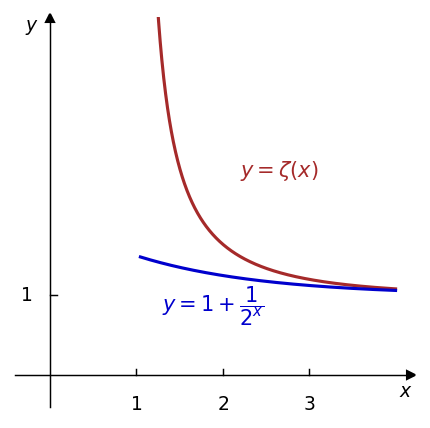

In [12]:
# ── 데이터 생성 ───────────────────────────────────────────────
x = np.linspace(1.05, 4.0, 800)
zeta_x = scipy_zeta(x)
f2_x   = 1 + 1 / 2**x

# ── 레이아웃 설정 ─────────────────────────────────────────────
x_axis_start = -0.4
x_axis_end   = 4.2

y_axis_start = -0.4
y_axis_end   = 4.5

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_xlim(x_axis_start, x_axis_end)
ax.set_ylim(y_axis_start, y_axis_end)

# ── 곡선 플롯 ─────────────────────────────────────────────────
ax.plot(x, zeta_x, color="brown", lw=LW_CURVE)
ax.plot(x, f2_x,   color="mediumblue", lw=LW_CURVE)

# ── 축 스타일 (교차 축 및 화살표) ─────────────────────────────
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_position(("data", 0))
ax.spines["left"].set_position(("data", 0))

# LW_TICK을 적용하여 축 선 두께 조절
ax.spines["bottom"].set_linewidth(LW_TICK)
ax.spines["left"].set_linewidth(LW_TICK)

# 축 화살표
ax.plot(x_axis_end - 0.02, 0, ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0, y_axis_end - 0.02, "^k", ms=MS_ARROW, clip_on=False)

# ── 축 레이블 (x, y) ──────────────────────────────────────────
ax.text(x_axis_end, -0.2, "$x$", va="center", ha="right", fontsize=FS_LABEL)
ax.text(-0.2, y_axis_end, "$y$", ha="center", va="top", fontsize=FS_LABEL)

# ── 눈금선(Tick) 및 눈금 레이블 직접 그리기 ───────────────────
# 이미지와 동일하게 축에 만나는 작은 눈금선(tick)을 LW_TICK 두께로 추가
tick_size = 0.08

for val in [1, 2, 3]:
    # x축 눈금선 및 레이블
    ax.plot([val, val], [0, tick_size], color="black", lw=LW_TICK)
    ax.text(val, -0.25, f"${val}$", ha="center", va="top", fontsize=FS_TICK)

# y축 눈금선 및 레이블 '1'
ax.plot([0, tick_size], [1, 1], color="black", lw=LW_TICK)
ax.text(-0.2, 1, "$1$", ha="right", va="center", fontsize=FS_TICK)

# ── 곡선 인라인 레이블 (위치 및 크기 적용) ───────────────────
# y = ζ(x)
ax.text(2.2, 2.5, r"$y = \zeta(x)$", color="brown", fontsize=FS_CURVE, ha="left")

# y = 1 + 1/2^x (파란 곡선 아래 배치)
ax.text(1.3, 0.8, r"$y = 1 + \dfrac{1}{2^x}$", color="mediumblue", fontsize=FS_CURVE, ha="left")

# ── 기본 틱 제거 ──────────────────────────────────────────────
ax.set_xticks([])
ax.set_yticks([])

# ── 저장 및 출력 ──────────────────────────────────────────────
plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-001.png"), bbox_inches="tight", dpi=300)
plt.show()

## Figure 2. Re(s) ≥ 1+a 영역에서의 uniform convergence 증명 구조

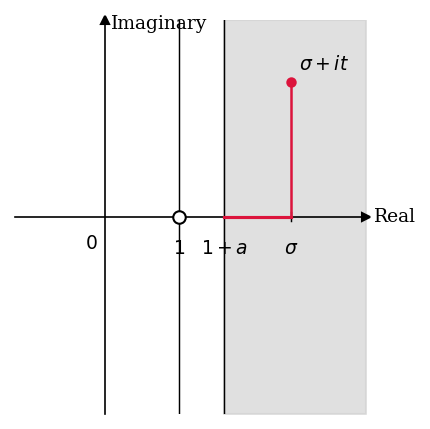

In [9]:
a     = 0.6
sigma = 2.5
t     = 1.5

x_min, x_max = -1.2, 3.5
y_min, y_max = -2.2, 2.2

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 회색 음영 반평면 Re(s) ≥ 1+a
ax.fill_betweenx([y_min, y_max], 1 + a, x_max,
                 color="lightgray", alpha=0.7, zorder=1)

# 축 스타일
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(x_max, 0,     ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     y_max, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,           "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.08,        y_max - 0.1, "Imaginary", ha="left",   fontsize=FS_LABEL)

# "0" 눈금
ax.text(-0.1, -0.2, "$0$", ha="right", va="top", fontsize=FS_TICK)

# Re(s) = 1 — 검은 실선 + 열린 원 (pole)
ax.plot([1, 1], [y_min, y_max], "k-", lw=LW_TICK, zorder=2)       # ← 추가
ax.plot(1, 0, "o", color="white", ms=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=4)
ax.text(1, -0.25, "$1$", ha="center", va="top", fontsize=FS_TICK)

# "1+a" 경계선
ax.plot([1 + a, 1 + a], [y_min, y_max], "k-", lw=LW_TICK, zorder=2)
ax.text(1 + a, -0.25, r"$1+a$", ha="center", va="top", fontsize=FS_TICK)

# "σ" 눈금
ax.plot([sigma, sigma], [-0.05, 0.05], "k-", lw=LW_TICK)
ax.text(sigma, -0.25, r"$\sigma$", ha="center", va="top", fontsize=FS_TICK)

# 빨간 실수축 선 (1+a → σ)
ax.plot([1 + a, sigma], [0, 0], color="crimson", lw=LW_RED, zorder=3)

# 빨간 수직선 (σ → σ+it)
ax.plot([sigma, sigma], [0, t], color="crimson", lw=LW_RED_V, zorder=3)

# 점 σ+it
ax.plot(sigma, t, "o", color="crimson", ms=MS_POINT, zorder=5)
ax.text(sigma + 0.1, t + 0.1,
        r"$\sigma + it$", ha="left", va="bottom", fontsize=FS_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-002.png"), bbox_inches="tight")
plt.show()

## Figure 3. ζ(s)가 analytic한 영역 Re(s) > 1

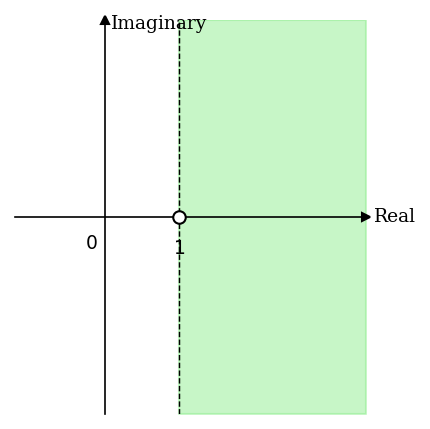

In [10]:
x_min, x_max = -1.2, 3.5
y_min, y_max = -2.2, 2.2

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 녹색 음영 반평면 Re(s) > 1
ax.fill_betweenx([y_min, y_max], 1, x_max,
                 color="lightgreen", alpha=0.5, zorder=1)

# 축 스타일
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(x_max, 0,     ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     y_max, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,          "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.08,        y_max - 0.1, "Imaginary", ha="left",   fontsize=FS_LABEL)

# "0" 눈금
ax.text(-0.1, -0.2, "$0$", ha="right", va="top", fontsize=FS_TICK)

# Re(s) = 1 경계: 점선 + 열린 원
ax.plot([1, 1], [y_min, y_max], "k--", lw=LW_TICK, zorder=2)
ax.plot(1, 0, "o", color="white", ms=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=4)
ax.text(1, -0.25, "$1$", ha="center", va="top", fontsize=FS_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-003.png"), bbox_inches="tight")
plt.show()